Here, we will calculate cointegration and hedge ratio. 
1. Set-up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

In [2]:
#load the data
prices = pd.read_csv(
    "../data/processed/clean_prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.dropna()

prices.head()

,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


2. Convert to log prices (This is because we want to do some linear combinations btwn KO and PEP prices)

In [3]:
log_prices = np.log(prices)

log_ko = log_prices["KO"]
log_pep = log_prices["PEP"]

We are modeling... 
log(P_KO) = a + blog(P_PEP) + e_t
The residual e_t becomes our spread. 

3. Estimate the hedge ratio b 

In [4]:
# OLS regression to find the hedge ratio
X = sm.add_constant(log_pep)

model = sm.OLS(log_ko, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     3793.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:13:20   Log-Likelihood:                 1062.1
No. Observations:                2202   AIC:                            -2120.
Df Residuals:                    2200   BIC:                            -2109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6047      0.074     -8.206      0.0

In [5]:
#Extract the alpha and the hedge ratio from the model

alpha = model.params["const"]
beta = model.params["PEP"]

print(f"Alpha: {alpha:.6f}")
print(f"Hedge ratio beta: {beta:.6f}")

Alpha: -0.604734
Hedge ratio beta: 0.936565


4. Construct the spread 

In [6]:
spread = log_ko - beta * log_pep

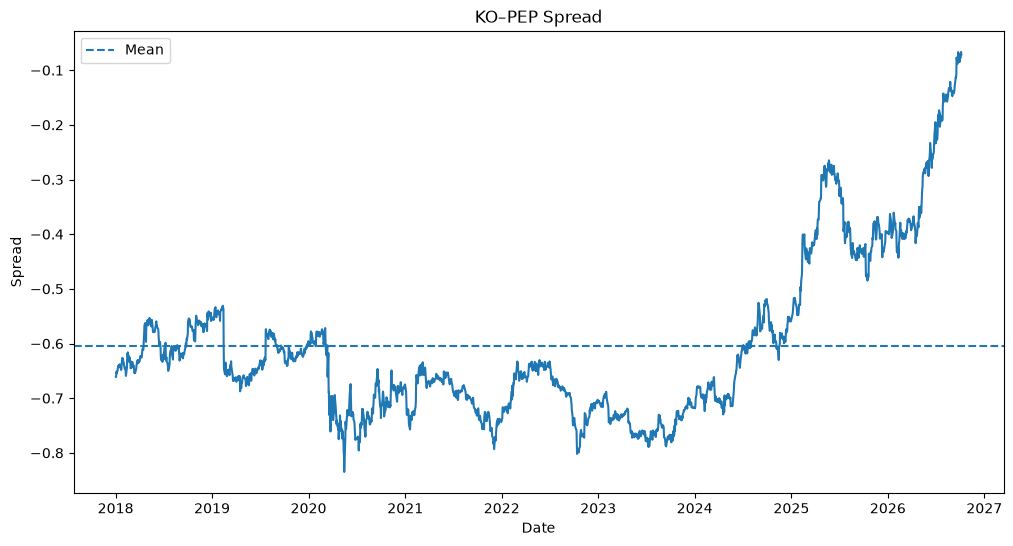

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(spread)

plt.axhline(
    spread.mean(),
    linestyle="--",
    label="Mean"
)

plt.title("KO–PEP Spread")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.legend()
plt.show()

From 2025, KO becomes relatively more expensive than PEP. 

5. Test for cointegration

In [8]:
score, pvalue, critical_values = coint(
    log_ko,
    log_pep
)

print(f"Cointegration statistic: {score:.4f}")
print(f"p-value: {pvalue:.6f}")

print("\nCritical values:")
print(f"1%:  {critical_values[0]:.4f}")
print(f"5%:  {critical_values[1]:.4f}")
print(f"10%: {critical_values[2]:.4f}")

Cointegration statistic: 0.7941
p-value: 0.993841

Critical values:
1%:  -3.9014
5%:  -3.3389
10%: -3.0464


Cointegration stat of 0.79 with the p-value of .994 indicates a strong coinegration btwn KO and PEP prices to a certain extent: might have happened by chance. 

6. Test the spread directly : stationarity and stability

In [9]:
#Augmented Dickey-Fuller test for stationarity of the spread

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(spread)

print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")

ADF statistic: 0.8285
p-value: 0.992082


/tmp/ipykernel_8341/1143995835.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(spread)


p~0.008 < 0.05 => statistically significant => the spread is stationary 

7. Save the research result 

In [10]:
results = pd.DataFrame({
    "spread": spread,
})

results.to_csv(
    "../data/processed/spread.csv"
)

print("Saved spread to data/processed/spread.csv")

Saved spread to data/processed/spread.csv


Now we have this pipeline... 
KO + PEP
   ↓
Log prices
   ↓
OLS regression
   ↓
Hedge ratio β
   ↓
Spread
   ↓
Cointegration test
   ↓
ADF stationarity test